<a href="https://colab.research.google.com/github/HakumenWorld/data-science-2026/blob/main/Pertemuan10_Febi_Kristiana_240401010231.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 10 — Algoritma Klasifikasi (Bagian 2)
## Aktivitas Hands-on: Customer Churn

**Mata Kuliah:** Pengantar Data Science  
**Nama:** Febi Kristiana

**NIM:** 240401010231

Notebook menggunakan **Telco Customer Churn** dan Random Forest.

Evaluasi WAJIB:
- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1-Score
- Interpretasi mengapa **Accuracy saja dapat menyesatkan pada dataset imbalanced**

## 1. Load Dataset

Notebook akan mencoba membaca dataset publik Telco Customer Churn secara otomatis.
Jika akses internet Colab tidak tersedia, notebook akan meminta Anda meng-upload file CSV secara manual.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_URL = (
    "https://raw.githubusercontent.com/IBM/"
    "telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
)

try:
    df = pd.read_csv(DATA_URL)
    print("Dataset berhasil dimuat dari URL publik.")
except Exception:
    from google.colab import files
    print("Download otomatis gagal. Silakan upload file Telco Customer Churn (.csv).")
    uploaded = files.upload()
    if not uploaded:
        raise FileNotFoundError("Tidak ada file CSV yang di-upload.")
    nama_file = next(iter(uploaded))
    df = pd.read_csv(nama_file)

print("Shape dataset:", df.shape)
display(df.head())

Dataset berhasil dimuat dari URL publik.
Shape dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. EDA Singkat dan Cek Imbalance

Distribusi target Churn:


,Jumlah,Proporsi
Churn,,
No,5174,0.7346
Yes,1869,0.2654


Proporsi pelanggan Churn (Yes): 26.54%


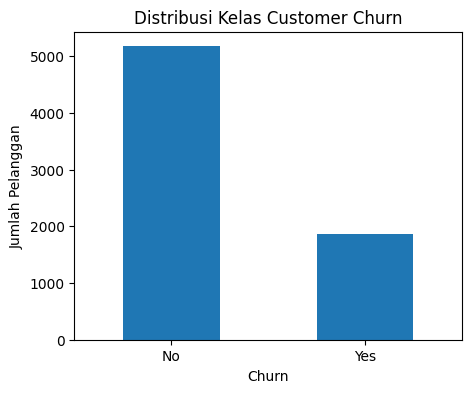


Interpretasi awal: jika kelas Churn (Yes) jauh lebih sedikit daripada No, dataset termasuk imbalanced.


In [ ]:
print("Distribusi target Churn:")
distribusi = df["Churn"].value_counts()
proporsi = df["Churn"].value_counts(normalize=True)

display(pd.DataFrame({
    "Jumlah": distribusi,
    "Proporsi": proporsi.round(4)
}))

churn_rate = proporsi.get("Yes", 0)
print(f"Proporsi pelanggan Churn (Yes): {churn_rate:.2%}")

plt.figure(figsize=(5, 4))
distribusi.reindex(["No", "Yes"]).plot(kind="bar")
plt.title("Distribusi Kelas Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Jumlah Pelanggan")
plt.xticks(rotation=0)
plt.show()

print(
    "\nInterpretasi awal: jika kelas Churn (Yes) jauh lebih sedikit daripada No, "
    "dataset termasuk imbalanced."
)

## 3. Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split

data = df.copy()

# TotalCharges pada dataset asli dapat memiliki nilai kosong/spasi.
if "TotalCharges" in data.columns:
    data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
    data["TotalCharges"] = data["TotalCharges"].fillna(data["TotalCharges"].median())

# Target: Yes = 1 (Churn), No = 0
y = data["Churn"].map({"Yes": 1, "No": 0})

X = data.drop(columns=["Churn"])

# customerID hanya identifier, bukan fitur prediktif.
if "customerID" in X.columns:
    X = X.drop(columns=["customerID"])

# Missing value
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].fillna(X[col].median())
    else:
        mode = X[col].mode(dropna=True)
        X[col] = X[col].fillna(mode.iloc[0] if len(mode) else "Unknown")

# One-Hot Encoding untuk fitur kategorikal
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Shape X setelah encoding:", X.shape)
print("Data train:", X_train.shape)
print("Data test :", X_test.shape)
print(f"Proporsi Churn pada data test: {y_test.mean():.2%}")

Shape X setelah encoding: (7043, 30)
Data train: (5634, 30)
Data test : (1409, 30)
Proporsi Churn pada data test: 26.54%


## 4. Latih Random Forest

Karena kelas Churn cenderung lebih sedikit, digunakan `class_weight="balanced"` agar model
memberi bobot lebih besar pada kelas minoritas.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Random Forest selesai dilatih.")

Random Forest selesai dilatih.


## 5. Confusion Matrix — Tabel dan Heatmap

Confusion Matrix:


,Prediksi No Churn,Prediksi Churn
Aktual No Churn,925,110
Aktual Churn,187,187


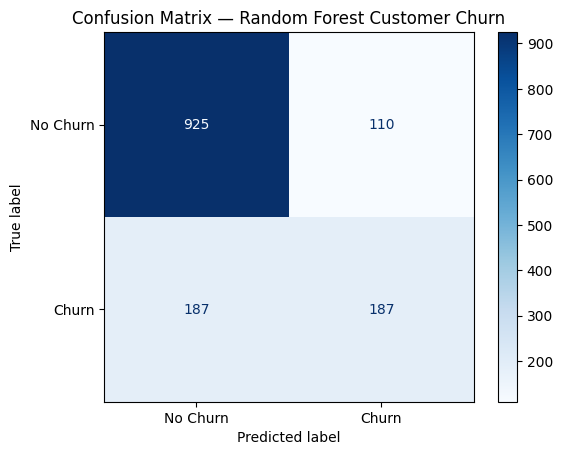

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

cm_df = pd.DataFrame(
    cm,
    index=["Aktual No Churn", "Aktual Churn"],
    columns=["Prediksi No Churn", "Prediksi Churn"]
)

print("Confusion Matrix:")
display(cm_df)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Random Forest Customer Churn")
plt.show()

## 6. Accuracy, Precision, Recall, dan F1-Score

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

metrics_df = pd.DataFrame({
    "Metrik": ["Accuracy", "Precision (Churn)", "Recall (Churn)", "F1-Score (Churn)"],
    "Nilai": [accuracy, precision, recall, f1]
})

display(metrics_df.style.format({"Nilai": "{:.4f}"}))

print(f"Accuracy          : {accuracy:.4f}")
print(f"Precision (Churn) : {precision:.4f}")
print(f"Recall (Churn)    : {recall:.4f}")
print(f"F1-Score (Churn)  : {f1:.4f}")

,Metrik,Nilai
0,Accuracy,0.7892
1,Precision (Churn),0.6296
2,Recall (Churn),0.5000
3,F1-Score (Churn),0.5574


Accuracy          : 0.7892
Precision (Churn) : 0.6296
Recall (Churn)    : 0.5000
F1-Score (Churn)  : 0.5574


## 7. Mengapa Accuracy Saja Bisa Menyesatkan?

In [ ]:
# Baseline sederhana: selalu memprediksi kelas mayoritas (No Churn)
prop_no_churn_test = (y_test == 0).mean()

print(f"Proporsi No Churn pada data test: {prop_no_churn_test:.4f}")
print(
    f"Jika model naif selalu memprediksi 'No Churn', "
    f"Accuracy-nya saja sudah sekitar {prop_no_churn_test:.2%}."
)

print(
    "\nKarena itu, Accuracy tinggi belum tentu berarti model bagus dalam menemukan pelanggan Churn. "
    "Model dapat terlihat akurat hanya karena sebagian besar pelanggan memang tidak churn."
)

Proporsi No Churn pada data test: 0.7346
Jika model naif selalu memprediksi 'No Churn', Accuracy-nya saja sudah sekitar 73.46%.

Karena itu, Accuracy tinggi belum tentu berarti model bagus dalam menemukan pelanggan Churn. Model dapat terlihat akurat hanya karena sebagian besar pelanggan memang tidak churn.


## 8. Interpretasi Metrik yang Paling Relevan untuk Customer Churn

In [ ]:
print(
    "INTERPRETASI CUSTOMER CHURN\n"
    "============================\n"
    f"Accuracy  = {accuracy:.4f}\n"
    f"Precision = {precision:.4f}\n"
    f"Recall    = {recall:.4f}\n"
    f"F1-Score  = {f1:.4f}\n\n"
    "Untuk dataset customer churn yang imbalanced, Accuracy tidak boleh digunakan sendirian. "
    "Recall Churn penting karena menunjukkan kemampuan model menemukan pelanggan yang benar-benar akan churn. "
    "False Negative pada kasus ini berarti pelanggan yang sebenarnya akan churn tidak terdeteksi sehingga "
    "perusahaan kehilangan kesempatan melakukan tindakan retensi.\n\n"
    "Precision juga penting agar program retensi tidak terlalu banyak diberikan kepada pelanggan yang sebenarnya "
    "tidak akan churn. F1-Score menjadi metrik ringkas yang relevan ketika ingin menyeimbangkan Precision dan Recall.\n\n"
    "Dalam konteks deteksi pelanggan berisiko, Recall Churn biasanya menjadi perhatian utama, sedangkan F1-Score "
    "berguna untuk melihat keseimbangan kemampuan deteksi dan ketepatan prediksi."
)

INTERPRETASI CUSTOMER CHURN
Accuracy  = 0.7892
Precision = 0.6296
Recall    = 0.5000
F1-Score  = 0.5574

Untuk dataset customer churn yang imbalanced, Accuracy tidak boleh digunakan sendirian. Recall Churn penting karena menunjukkan kemampuan model menemukan pelanggan yang benar-benar akan churn. False Negative pada kasus ini berarti pelanggan yang sebenarnya akan churn tidak terdeteksi sehingga perusahaan kehilangan kesempatan melakukan tindakan retensi.

Precision juga penting agar program retensi tidak terlalu banyak diberikan kepada pelanggan yang sebenarnya tidak akan churn. F1-Score menjadi metrik ringkas yang relevan ketika ingin menyeimbangkan Precision dan Recall.

Dalam konteks deteksi pelanggan berisiko, Recall Churn biasanya menjadi perhatian utama, sedangkan F1-Score berguna untuk melihat keseimbangan kemampuan deteksi dan ketepatan prediksi.


## Kesimpulan

Customer Churn merupakan kasus klasifikasi dengan distribusi kelas yang cenderung tidak seimbang.
Oleh sebab itu, **Accuracy saja dapat memberikan gambaran yang terlalu optimistis**. Model yang sering
memprediksi kelas mayoritas `No Churn` masih dapat memperoleh Accuracy tinggi walaupun gagal menemukan
banyak pelanggan yang benar-benar churn.

Untuk kasus ini, **Recall pada kelas Churn sangat relevan** karena menunjukkan kemampuan model mendeteksi
pelanggan yang benar-benar berisiko berhenti. Semakin tinggi Recall, semakin sedikit pelanggan churn
yang terlewat (*False Negative*). Namun Precision tetap perlu diperhatikan agar tindakan retensi tidak
terlalu banyak diberikan pada pelanggan yang sebenarnya tidak churn. Karena itu, **F1-Score** juga berguna
sebagai ukuran keseimbangan Precision dan Recall.